## Historisk rekonstruktion av grundvattennivå med omkalibrerad modell

Denna notebook kalibrerar om grundvattenmodellen med samma modellstruktur som i kalibreringsnotebooken för PET-metoden FAO-24 och använder sedan modellen för hindcasting före observationsperioden.

Steg:
1. Importera bibliotek
2. Läs in indata och kalibreringsperiod
3. Kalibrera modell med FAO-24
4. Kör hindcasting
5. Exportera resultat till Excel

### 0. Importera bibliotek

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pastas as ps

### 1. Läs in indata och definiera kalibreringsperiod

In [2]:
# Alla in- och utdatafiler i denna workflow ligger i ../data
data_dir = "../data"

prec = pd.read_csv(
    os.path.join(data_dir, "precip_data_km.csv"),
    index_col=0,
    parse_dates=[0],
    date_format="%Y-%m-%d"
).squeeze("columns")

temp = pd.read_csv(
    os.path.join(data_dir, "temp_data_km.csv"),
    index_col=0,
    parse_dates=[0],
    date_format="%Y-%m-%d"
).squeeze("columns")

evap = pd.read_csv(
    os.path.join(data_dir, "pet_data_km.csv"),
    index_col=0,
    parse_dates=[0],
    date_format="%Y-%m-%d"
)

evap_choice = "FAO-24"
if evap_choice not in evap.columns:
    raise KeyError(f"PET-metoden '{evap_choice}' finns inte i pet_data_km.csv")
evap_selected = evap[evap_choice]

ho_file = os.path.join(data_dir, "head_abs_km_compensated_daily.xlsx")
if not os.path.exists(ho_file):
    raise FileNotFoundError(f"Grundvattenfil saknas: {ho_file}")

ho = pd.read_excel(ho_file, usecols=[0, 1], index_col=0, parse_dates=True).squeeze()
ho.name = "ho"

tmin_cal = "2022-12-22"
tmax_cal = "2024-02-19"

print(f"Vald PET-metod: {evap_choice}")
print(f"Längd prec/temp/evap: {len(prec)}/{len(temp)}/{len(evap_selected)}")
print(f"Antal observationer: {len(ho)}")
print(f"Kalibreringsperiod: {tmin_cal} till {tmax_cal}")

Vald PET-metod: FAO-24
Längd prec/temp/evap: 10945/10942/10928
Antal observationer: 806
Kalibreringsperiod: 2022-12-22 till 2024-02-19


### 2. Kalibrera modell med FAO-24

In [ ]:
# Workaround för Pastas/pandas på strikt daglig observationsserie
ho_model = ho.copy()
if pd.infer_freq(ho_model.index) == "D":
    ho_model.index = ho_model.index + pd.to_timedelta(np.arange(len(ho_model)) % 2, unit="s")

gw_model = ps.Model(ho_model, name="my_model")

rm = ps.rch.FlexModel(
    gw_uptake=True,
    snow=True
)

sm = ps.RechargeModel(
    prec,
    evap_selected,
    temp=temp,
    recharge=rm,
    rfunc=ps.Gamma(),
    name="rch"
 )

gw_model.add_stressmodel(sm)
gw_model.set_parameter("rch_kv", vary=True)

# Steg 1
gw_model.solve(
    tmin=tmin_cal,
    tmax=tmax_cal,
    fit_constant=False,
    report=False,
    solver=ps.LeastSquares()
 )

gw_model.set_parameter("rch_srmax", vary=False)
gw_model.add_noisemodel(ps.ArNoiseModel())

# Steg 2
gw_model.solve(
    tmin=tmin_cal,
    tmax=tmax_cal,
    fit_constant=False,
    initial=False,
    report=False,
    solver=ps.LeastSquares()
 )

# Hindcastperiod: första samtidiga datum i drivserier till dagen före första observation
tmin_hindcast = max(prec.index.min(), temp.index.min(), evap_selected.index.min())
forcing_tmax = min(prec.index.max(), temp.index.max(), evap_selected.index.max())
tmax_hindcast = min(forcing_tmax, ho.index.min() - pd.Timedelta(days=1))


print(f"Modell kalibrerad: {gw_model.name}")
print(f"Hindcastperiod: {tmin_hindcast.date()} till {tmax_hindcast.date()}")
print(gw_model.parameters[["initial", "optimal", "vary"]].head())

The Time Series 'Prec' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Temp' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.


Modell kalibrerad: my_model
Hindcastperiod: 1996-01-01 till 2022-12-06
              initial    optimal   vary
rch_A        1.222916   1.110290   True
rch_n        1.588297   2.012959   True
rch_a      172.129861  84.010199   True
rch_srmax   16.961806  16.961806  False
rch_lp       0.250000   0.250000  False


### 3. Kör hindcasting

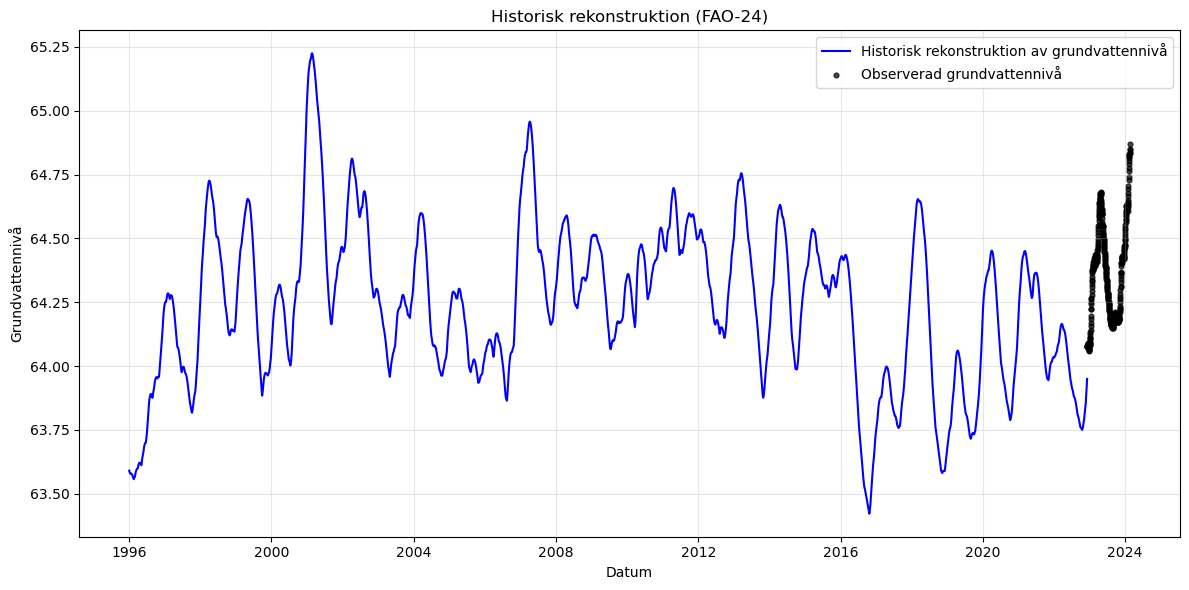

Period för historisk rekonstruktion: 1996-01-01 till 2022-12-06
Antal rekonstruerade dagar: 9837
1996-01-01    63.590822
1996-01-02    63.589688
1996-01-03    63.588516
1996-01-04    63.587306
1996-01-05    63.586059
Freq: D, Name: Simulation, dtype: float64


In [9]:
gw_head_hindcast = gw_model.simulate(tmin=tmin_hindcast, tmax=tmax_hindcast)
# Observerad data i samma period
ho_overlap = ho[tmax_hindcast:tmax_cal]

plt.figure(figsize=(12, 6))
plt.plot(gw_head_hindcast.index, gw_head_hindcast, label="Historisk rekonstruktion av grundvattennivå", color="blue")
plt.scatter(ho_overlap.index, ho_overlap, label="Observerad grundvattennivå", color="black",s=12, alpha=0.7)
plt.title(f"Historisk rekonstruktion ({evap_choice})")
plt.xlabel("Datum")
plt.ylabel("Grundvattennivå")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Period för historisk rekonstruktion: {tmin_hindcast.date()} till {tmax_hindcast.date()}")
print(f"Antal rekonstruerade dagar: {len(gw_head_hindcast)}")
print(gw_head_hindcast.head())

### 4. Exportera hindcastingresultat

In [ ]:
safe_method = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in evap_choice)

hindcast_xlsx = os.path.join(data_dir, f"hindcast_{safe_method}.xlsx")

gw_head_hindcast.to_excel(hindcast_xlsx, index=True)

print(f"Hindcast sparad till Excel: {hindcast_xlsx}")